In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
import sympy as sp
from numpy.polynomial.chebyshev import chebvander
from numpy.polynomial.chebyshev import Chebyshev
from numpy.polynomial.polynomial import Polynomial


Text(0.5, 0, 's')

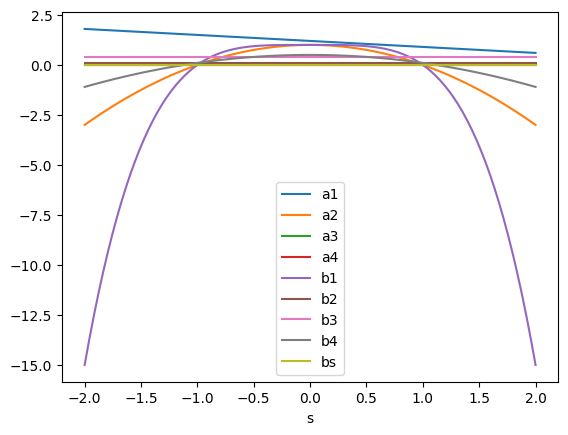

In [3]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
# a_coeffs = ["3.4/(exp(s)+exp(-s))","-0.5*s**2+1.2",0.3,0.5]
# b_coeffs = ["2*exp(-s**2)",0.5,"1/(1+s**2)**1.5",0.05]
a_coeffs = ["1.2-0.3*s", "1-s**2", 0.02, 0.002]
b_coeffs = ["1-s**4",0.1,0.4, "0.5-0.4*s**2"]
#get bpmeth opbject
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs, nphi=6)
expansion.plot_components()
plt.xlabel('s')
#plt.xlim((-1,1))

Scalar potential phi(x,y,s): -8.33333333333333e-5*x**4 - 0.00333333333333333*x**3 - x**2*(1 - s**2)/2 - x*(1.2 - 0.3*s) - y**5*(-9.6*x - 144)/720 + 0.166583333333333*y**4 + y**3*(-72*s**2 - 0.8*x**3 + 6*x*(0.5 - 0.4*s**2) + 2.4)/36 + y**2*(-24*s**2 - 23.976*x**2 + 0.48*x + 24)/48 - y*(-6*s**4 + x**3*(0.5 - 0.4*s**2) + 1.2*x**2 + 0.6*x + 6)/6
Scalar potential phi at (0.4,0.2,0.5): -0.6739380711111111


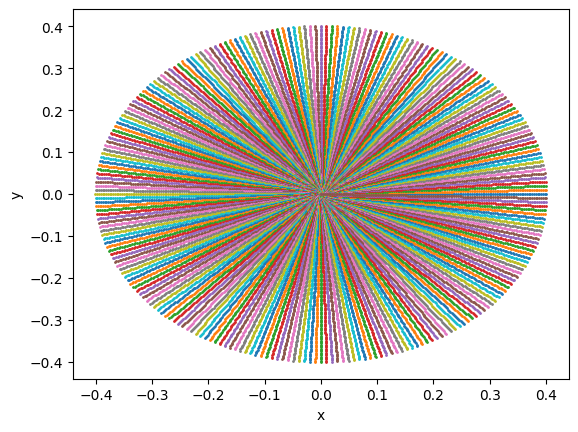

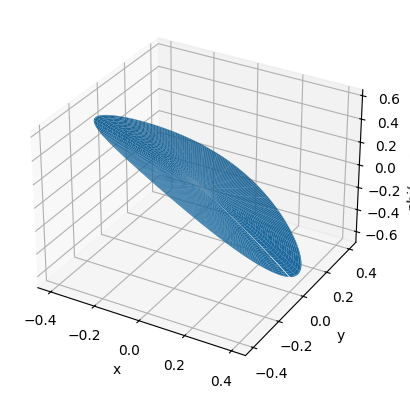

In [4]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define r, theta, s axes to convert the symbolic expression of phi into a numerical array
rmin, rmax, nr = 0.001, 0.401, 128
ntheta = 256
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-0.5,0.5, 101)

rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=1)
plt.xlabel("x")
plt.ylabel("y")
P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0],P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [5]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)
print(By_ana.shape)

(128, 256, 101)


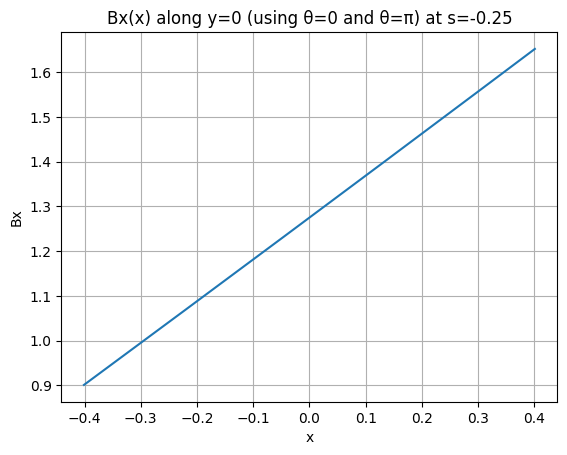

In [5]:
#Plot Bx as a function of x for y=0, fixed s
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
Bx_pos = Bx_ana[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
Bx_neg = Bx_ana[:, itheta_neg, :]

# Combine and sort
x_all = np.concatenate([x_neg, x_pos])
Bx_ofx = np.concatenate([Bx_neg, Bx_pos])

order = np.argsort(x_all[:,0])
x_all = x_all[order]
Bx_ofx = Bx_ofx[order]

plt.plot(x_all[:,islice], Bx_ofx[:,islice])
plt.xlabel("x")
plt.ylabel("Bx")
plt.title("Bx(x) along y=0 (using θ=0 and θ=π) at s="+str(ss[islice]))
plt.grid(True)


(256, 101) (256, 101)
(256, 101) (256, 101)


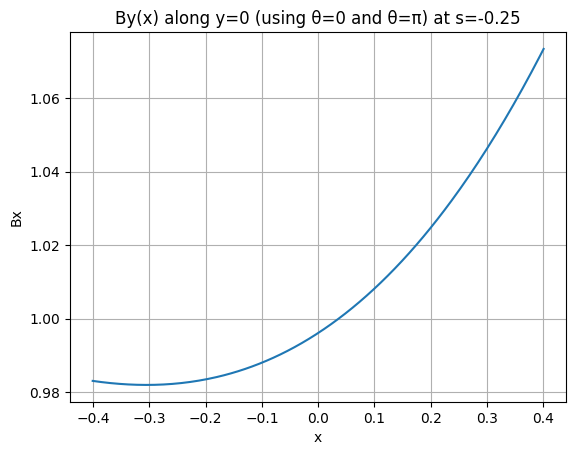

In [6]:
#Plot By as a function of x for y=0, fixed s
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
By_pos = By_ana[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
By_neg = By_ana[:, itheta_neg, :]
#print(x_neg.shape, By_neg.shape, x_pos.shape, By_pos.shape)
# Combine and sort
x_all = np.concatenate([x_neg, x_pos], axis=0)
By_ofx = np.concatenate([By_neg, By_pos])
print(x_all.shape, By_ofx.shape)
order = np.argsort(x_all[:,0])
x_all = x_all[order]
By_ofx = By_ofx[order]
print(x_all.shape, By_ofx.shape)
plt.plot(x_all[:,islice], By_ofx[:,islice])
plt.xlabel("x")
plt.ylabel("Bx")
plt.title("By(x) along y=0 (using θ=0 and θ=π) at s="+str(ss[islice]))
plt.grid(True)


In [9]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)#with lambdify False
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [10]:
#itheta_pos = np.argmin(np.abs(tt - np.pi/2))
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    #dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    #dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    #dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)
    def grad_periodic(f, dtheta, axis=1):
        return (np.roll(f, -1, axis=axis) - np.roll(f, 1, axis=axis)) / (2 * dtheta)

   #tell np.grad to use periodic boundary conditions for the theta derivative. otherwise at theta=0 it will use one-sided differences
    dAz_dtheta     = grad_periodic(Az_cyl, dtheta)
    dAr_dtheta     = grad_periodic(Ar,     dtheta)
    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_dz     = np.gradient(Ar,     ds, axis=2)
    dAtheta_dz = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_dz
    curl_theta = dAr_dz - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z
    #   # On the theta=pi/2 slice, curl_y ≈ curl_r (cos term vanishes)
    # # Decompose curl_r:
    # term1 = (1/rarr[:, itheta_pos, islice]) * dAz_dtheta[:, itheta_pos, islice]
    # term2 = dAtheta_dz[:, itheta_pos, islice]

    # plt.figure()
    
    # y_pos = yarr[:,itheta_pos, islice]
    # plt.plot(y_pos, term1, label='(1/r)*dAz_dtheta')
    # plt.plot(y_pos, term2, label='dAtheta_dz')
    # plt.plot(y_pos, term1 - term2, label='curl_r = curl_y')
    # plt.plot(y_pos, By_ana[:, itheta_pos, islice], label='By_ana')
    # plt.legend(); plt.grid(True)
    # plt.title("Decomposition of curl_y at theta=pi/2")
    # plt.show()
    # # Check curl_theta contribution (which vanishes at theta=pi/2 for curl_y)
    # ir_mid=nr//2
    # print("curl_theta at r=0.5, theta=pi/2:", curl_theta[ir_mid, itheta_pos, islice])
    # print("curl_r    at r=0.5, theta=pi/2:", curl_r[ir_mid,    itheta_pos, islice])
    # print("By_ana    at r=0.5, theta=pi/2:", By_ana[ir_mid,    itheta_pos, islice])
    # # Check if these are consistent
    # dAz_dx_direct = np.gradient(As_ana[:, itheta_pos, islice], 
    #                             xarr[:, itheta_pos, islice])  # direct x-derivative along the slice
    # dAz_dtheta_at_pos = dAz_dtheta[:, itheta_pos, islice]
    # r_at_pos = rarr[:, itheta_pos, islice]

    # plt.plot(yarr[:, itheta_pos, islice], dAz_dx_direct, label='dAz/dx direct')
    # plt.plot(yarr[:, itheta_pos, islice], -dAz_dtheta_at_pos / r_at_pos, label='-(1/r)*dAz/dtheta')
    # plt.legend(); plt.grid(True)
    # plt.show()
    # ir_max = -1  # outermost r
    # print("Ax at rmax:", Ax_ana[ir_max, itheta_pos, islice])
    # print("As at rmax:", As_ana[ir_max, itheta_pos, islice])
    # print("dAtheta_dz at rmax:", dAtheta_dz[ir_max, itheta_pos, islice])
    # print("dAz_dtheta/r at rmax:", dAz_dtheta[ir_max, itheta_pos, islice] / rmax)
    # # Compare numerical vs analytical dAx_ds at theta=pi/2
    # dAx_ds_numerical = np.gradient(Ax_ana[:, itheta_pos, :], ds, axis=1)

    # # If you have the symbolic derivative:
    # import sympy as sp
    # dAx_ds_sym = sp.diff(Ax, s)
    # dAx_ds_ana = np.vectorize(sp.lambdify([x, y, s], dAx_ds_sym, "numpy"))(
    #     xarr[:, itheta_pos, :], yarr[:, itheta_pos, :], sarr[:, itheta_pos, :]
    # )

    # plt.plot(rr, dAx_ds_numerical[:, islice], label='numerical dAx/ds')
    # plt.plot(rr, dAx_ds_ana[:, islice], label='analytical dAx/ds')
    # plt.legend(); plt.grid(True)
    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
#print(curl_x.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))




Max difference in Bx: 0.0018359034750330405
Max relative difference in By: 0.0034166503222632346
Max difference in Bs: 0.0057970595315536425


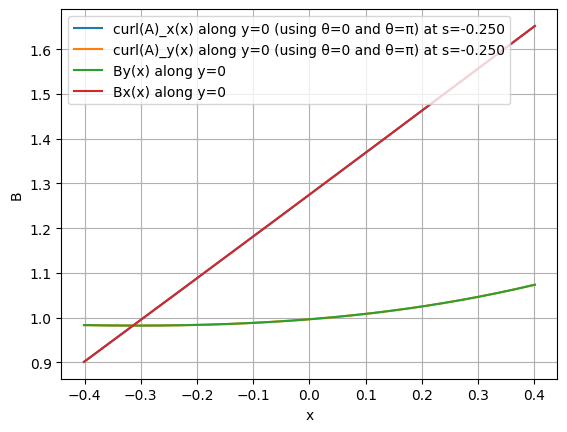

In [9]:
#Plot curlx as a function of x for y=0
islice = 25   # choose an s index
# θ = 0 → positive x
itheta_pos = np.argmin(np.abs(tt - 0))
x_pos = xarr[:,itheta_pos, :]
curlx_pos = curl_x[:, itheta_pos, :]

# θ = π → negative x
itheta_neg = np.argmin(np.abs(tt - np.pi))
x_neg = xarr[:,itheta_neg, :]
curlx_neg = curl_x[:, itheta_neg, :]

# Combine and sort
x_all = np.concatenate([x_neg, x_pos])
curlx_ofx = np.concatenate([curlx_neg, curlx_pos])

order = np.argsort(x_all[:,0])
x_all = x_all[order]
curlx_ofx = curlx_ofx[order]

plt.plot(x_all[:,islice], curlx_ofx[:,islice], label="curl(A)_x(x) along y=0 (using θ=0 and θ=π) at s="+str(f"{ss[islice]:.3f}"))
plt.xlabel("x")
plt.ylabel("B")

plt.grid(True)
#plot curly as a function of x for y=0

curly_pos = curl_y[:, itheta_pos, :]
curly_neg = curl_y[:, itheta_neg, :]

# Combine and sort
curly_ofx = np.concatenate([curly_neg, curly_pos])
curly_ofx = curly_ofx[order]

plt.plot(x_all[:,islice], curly_ofx[:,islice], label="curl(A)_y(x) along y=0 (using θ=0 and θ=π) at s="+str(f"{ss[islice]:.3f}"))
plt.plot(x_all[:,islice], By_ofx[:,islice], label='By(x) along y=0')
plt.plot(x_all[:,islice], Bx_ofx[:,islice], label='Bx(x) along y=0')
plt.legend()
# plt.xlim((-.1,.6))
# plt.ylim((-0.02,0.4))
plt.show()



(128, 256, 101)
11


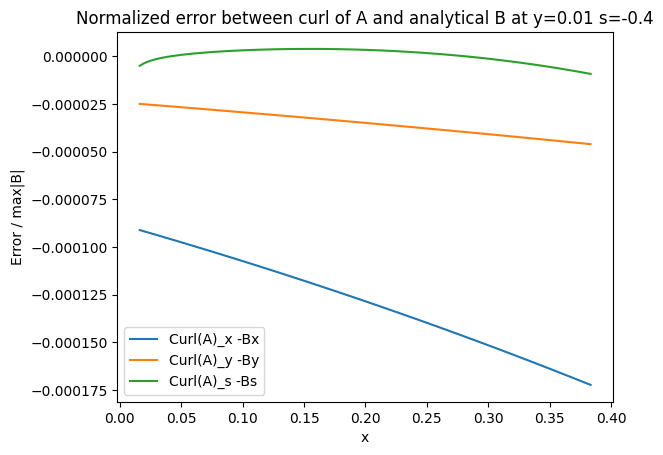

In [10]:
npoints=len(xarr)
print(xarr.shape)
truncatedxarr=xarr[5:npoints-1,11,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(5,npoints-1), 11, 10)#all x, y=fixed, s=fixed
print(position[1])
Bmaxx=np.max([np.max(Bx_ana),np.max(By_ana),np.max(Bs_ana)])
plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/Bmaxx, label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/Bmaxx, label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/Bmaxx, label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_y[position]-By_ana[position])/By_ana[position]), np.max((curl_y[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Normalized error between curl of A and analytical B at y='+str(np.round(yarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.ylabel('Error / max|B|')
plt.show()


Text(0.5, 0, 'x')

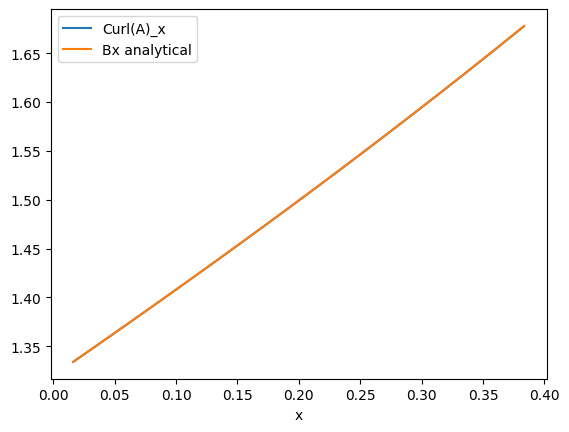

In [11]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

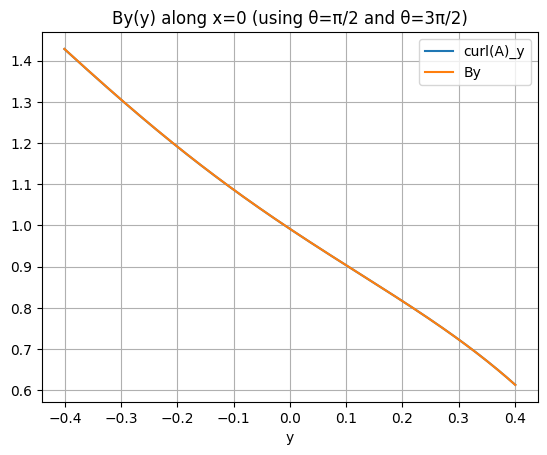

In [11]:
#plot y component of field as function of y for x=0
islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]
By_pos= By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]
By_neg= By_ana[:, itheta_neg, islice]
# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
By_all = np.concatenate([By_neg, By_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]
By_all =By_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")

plt.legend()
plt.grid(True)


/tmp/fmarcoli/ipykernel_113677/2662422590.py:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_plane, y_plane, err_plane, shading='auto')


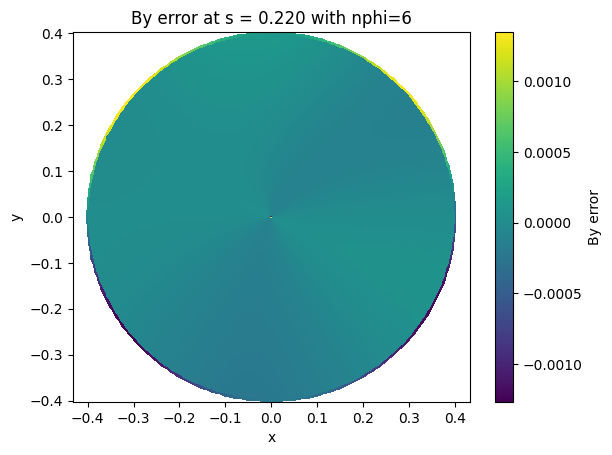

In [12]:
errBy=curl_y-By_ana
k = 72

x_plane = xarr[:, :, k]
y_plane = yarr[:, :, k]
err_plane = errBy[:, :, k]

plt.figure()
plt.pcolormesh(x_plane, y_plane, err_plane, shading='auto')
plt.colorbar(label='By error')
plt.title(f'By error at s = {ss[k]:.3f} with nphi=6')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

HA of curl(A) (on the grid)

In [13]:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitrawcut(dkofrarray, rr, nk, nl, rmin_fit=None):
    '''
    rmin_fit: minimum r to include in the fit (to avoid blow-up of dk/r^|k| at small r).
              Defaults to rr.max() * 0.6 if not given.
    '''
    if rmin_fit is None:
        rmin_fit = rr.max() * 0.6

    mask = rr >= rmin_fit
    rr_fit = rr[mask]
    dkofr_fit = dkofrarray[mask, :]

    polynomial = np.zeros((len(rr_fit), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_fit):
        polynomial[ir, 0]    = dkofr_fit[ir, 0]
        polynomial[ir, 1::2] = dkofr_fit[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofr_fit[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_fit**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfitraw_nodiv(dkofrarray, rr, nk, nl):
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    kpos = np.arange(1, nk+1)

    # k=0: exponents are 0, 2, 4, ..., 2*(nl-1)
    V0 = np.column_stack([rr**(2*l) for l in range(nl)])
    dkl[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(kpos):
        # exponents are k, k+2, k+4, ..., k+2*(nl-1)
        V = np.column_stack([rr**(k + 2*l) for l in range(nl)])
        col_pos = 2*ik + 1
        col_neg = 2*ik + 2
        dkl[col_pos, :] = np.linalg.lstsq(V, dkofrarray[:, col_pos], rcond=None)[0]
        dkl[col_neg, :] = np.linalg.lstsq(V, dkofrarray[:, col_neg], rcond=None)[0]

    return dkl

def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):                                                                                        
    """
    Numerically stable Chebyshev version of dklfitraw_nodiv.
    Fits     f_k(r) ≈ Σ_l dkl[k,l] r^{|k|+2l}
    exactly like dklfitraw_nodiv, but internally uses a
    Chebyshev basis in x = r^2 for improved conditioning.
    Returns
    -------
    dkl : complex ndarray, shape (2*nk+1, nl)
        Coefficients with exactly the same meaning as dklfitraw_nodiv:  f_k(r) ≈ Σ_l dkl[k,l] r^{|k|+2l}
    """
    dkl = np.zeros((2*nk + 1, nl), dtype=complex)
    x = rr**2
    xmin = x.min()
    xmax = x.max()
    s = 2*(x - xmin)/(xmax - xmin) - 1 # scale x -> s in [-1,1]
    # Chebyshev Vandermonde in scaled variable
    T = chebvander(s, nl-1)
    # k ordering:
    # [0, +1, -1, +2, -2, ...]
    for ik in range(2*nk + 1):
        if ik == 0:
            kabs = 0
        else:
            kabs = (ik + 1)//2
        # absorb r^|k| into the matrix itself
        A = (rr[:, None]**kabs) * T
        y = dkofrarray[:, ik]
        # stable least squares in Chebyshev basis
        c_re, _, _, _ = np.linalg.lstsq(A, y.real, rcond=None)
        c_im, _, _, _ = np.linalg.lstsq(A, y.imag, rcond=None)
        c = c_re + 1j*c_im
        # Convert:  Σ c_n T_n(s)    into ordinary polynomial in x=r^2: Σ a_l x^l
        cheb = Chebyshev(c, domain=[xmin, xmax])
        poly = cheb.convert(kind=Polynomial)
        coeffs = poly.coef
        # store coefficients of x^l so total basis is    r^|k| * (r^2)^l = r^{|k|+2l}
        ncopy = min(len(coeffs), nl)
        dkl[ik, :ncopy] = coeffs[:ncopy]
    return dkl

#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_cut(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitrawcut(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_nodiv(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn


s fixed= 0.21999999999999997
(128, 256, 101)


/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


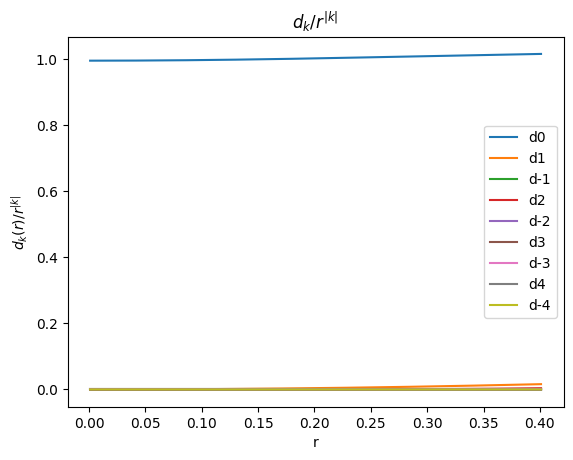

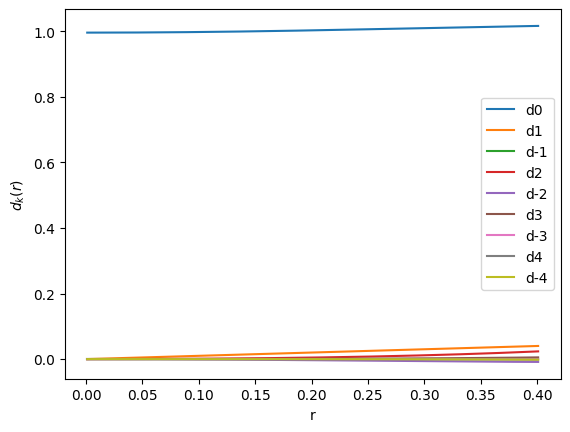

In [14]:
nk=4
nl=nk//2+1
sindex=72
s_fixed=ss[sindex]
print("s fixed=",s_fixed)
curlyix=curl_y+1j*curl_x
origByiBx=By_ana+1j*Bx_ana #to check from the original field
fieldyplusifieldx=origByiBx # origByiBx or curlyix
print(fieldyplusifieldx.shape)
dkgridout=dkongrid(Byibx_rts=fieldyplusifieldx, rr=rr, nk=nk,s_index=25)
#plot dk(r)/r^|k|
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki+1)/2), label='d'+str((ki+1)//2))#for some reason i have to put a - in the exponent
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki)/2), label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)/r^{|k|}$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title('$d_k/r^{|k|}$')
plt.show()
#plot d_k(r)
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str((ki+1)//2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.show()


In [15]:
griddkl_nodiv=dklfitraw_nodiv(dkofrarray=dkgridout ,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(griddkl_nodiv)
griddkl_nodiv_cheb=dklfitraw_nodiv_cheb(dkofrarray=dkgridout ,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(griddkl_nodiv_cheb)
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
b_eva = lambdify(s, b_coeffs, modules='numpy')
a_eva = lambdify(s, a_coeffs, 'numpy')


#recover them with different variation of the HA method:
acurl_nodiv_cheb, bcurl_nodiv_cheb = LHongrid_nodiv_cheb(ByiBxongrid=fieldyplusifieldx, s_index=sindex, nk=nk)
acurl_cut, bcurl_cut = LHongrid_cut(ByiBxongrid=fieldyplusifieldx, s_index=sindex, nk=nk)
acurl_nodiv, bcurl_nodiv = LHongrid_nodiv(ByiBxongrid=fieldyplusifieldx, s_index=sindex, nk=nk)
print("a_n from curl by no div cheb", acurl_nodiv_cheb)
print("b_n from curl by no div cheb", bcurl_nodiv_cheb)
print(f"original a_n(s={s_fixed:.3f}) = {a_eva(s_fixed)}")
print(f"original b_n(s={s_fixed:.3f}) = {b_eva(s_fixed)}")
print("a_n from curl by cut", acurl_cut)
print("b_n from curl by cut", bcurl_cut)
print("a_n from curl by no div", acurl_nodiv)
print("b_n from curl by no div", bcurl_nodiv)

columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[ 0.996+1.275j  0.188+0.j    -0.375-0.j   ]
 [ 0.1  +0.938j  0.   +0.25j  -0.   +0.j   ]
 [ 0.   +0.j     0.   -0.j    -0.   +0.j   ]
 [ 0.106+0.01j   0.25 +0.j    -0.   -0.j   ]
 [-0.094-0.j     0.25 +0.j     0.   -0.j   ]
 [ 0.079-0.333j  0.008-0.j    -0.   +0.j   ]
 [ 0.   +0.083j -0.   +0.j     0.   -0.j   ]
 [-0.062+0.j    -0.   -0.j     0.   +0.j   ]
 [-0.062-0.j    -0.   +0.j     0.   -0.j   ]]
columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[ 0.996+1.275j  0.188+0.j    -0.375-0.j   ]
 [ 0.1  +0.938j -0.   +0.25j  -0.   -0.j   ]
 [ 0.   +0.j     0.   -0.j    -0.   +0.j   ]
 [ 0.106+0.01j   0.25 +0.j    -0.   -0.j   ]
 [-0.094-0.j     0.25 +0.j    -0.   -0.j   ]
 [ 0.079-0.333j  0.008-0.j    -0.   +0.j   ]
 [ 0.   +0.083j -0.   +0.j     0.   -0.j   ]
 [-0.062+0.j    -0.   -0.j     0.   +0.j   ]
 [-0.062-0.j    -0.   +0.j     0.   -0.j   ]]
a_n from curl by no div cheb [1.134 0.952 0.02  0.002]
b_n from curl by no div cheb [0.998 0.1   0.4  

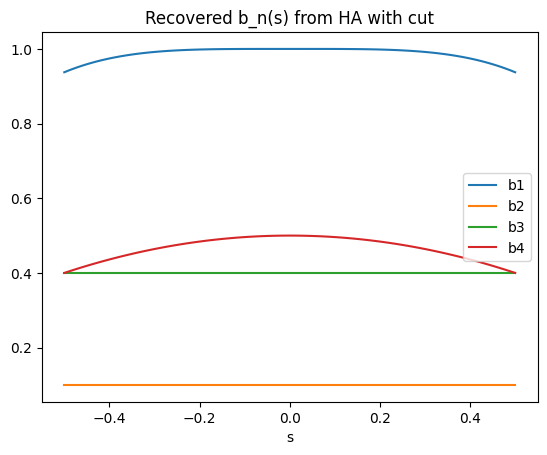

In [16]:
#HA as a function of s:
def LH_s_grid_cut(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))
    aofs = np.zeros((len(svals), korder))
    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        aofs[i], bofs[i] = LHongrid_cut(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, aofs, bofs
sss, aofs_cut ,bofs_cut = LH_s_grid_cut(fieldyix=fieldyplusifieldx,ss=ss, korder=4)
for j in range(bofs_cut.shape[1]):
    plt.plot(sss, bofs_cut[:,j], label='b'+str(j+1))
plt.legend()
plt.xlabel('s')
plt.title('Recovered b_n(s) from HA with cut')
plt.show()

bpmeth at fixed s DIRECTLY FROM FROM B

In [18]:
origfieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
origfieldmap =bpmeth.fieldmaps.Fieldmap(origfieldmap)


In [19]:
s_fixed = ss[sindex]
print(s_fixed)

0.21999999999999997


In [20]:
bnianfromB=origfieldmap.harmonic_analysis_at_s(spos=s_fixed, order=4, rmin=rmin, rmax=rmax, nr=nr, ntheta=ntheta ,radius=0.01 )
bnori=bnianfromB.real[:len(b_coeffs)]
anori=bnianfromB.imag[:len(a_coeffs)]

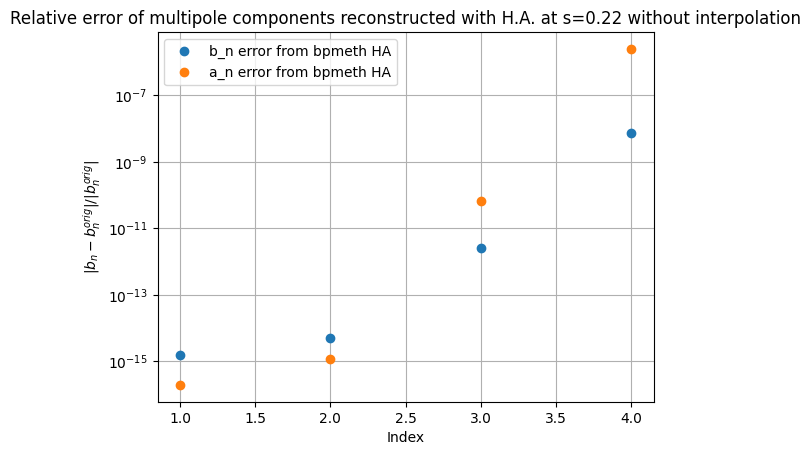

In [21]:
p=4#how many values to plot
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bnori[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from bpmeth HA')
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-anori[:p])/a_eva(s_fixed)[:p], 'o', label='a_n error from bpmeth HA')
plt.grid(True)
plt.yscale('log')
plt.xlabel('Index')
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(round(s_fixed,4))+' without interpolation' )
plt.show()

bpmeth on the result of the CURL

In [22]:
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed, order=4, rmin=rmin, rmax=rmax, nr=nr, radius=0.01 )

bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn: ",bn )
print("Original bn: ", b_coeffs)
print("recovered an: ", an )
print("Original an: ", a_coeffs)

KeyboardInterrupt: 

In [ ]:
#When there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.006)
bnfft=bnianfft.real[:len(b_coeffs)]
anfft=bnianfft.imag[:len(a_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [1.004 0.1   0.279 0.483]
Original bn:  ['1-s**4', 0.1, 0.4, '0.5-0.4*s**2']


In [ ]:
#FD derivatives in midplane for comparison
def derivativesFromField(x, B_i, max_order): #i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(ss)))
    dBvector[0,:,:] = B_i[:, :] #0th derivative: take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(x_all[:,0] - 0)) #index of the x value closest to zero

dBxvector=derivativesFromField(x_all[:,0], Bx_ofx, max_order)
dByvector=derivativesFromField(x_all[:,0], By_ofx, max_order)
a_FD=np.zeros((max_order,len(ss)))
b_FD=np.zeros((len(b_coeffs),len(ss)))
a_FD[:,:]=dBxvector[:max_order,idx_zero,:]
b_FD[:,:]=dByvector[:max_order,idx_zero,:]
print("a_n from finite differences at s="+str(f"{s_fixed:.3}")+": ", a_FD[:,25] )
print("b_n from finite differences: ", b_FD[:,25] )
print("Original a_nat s="+str(f"{s_fixed:.3}")+": ", a_eva(s_fixed))
print("Original b_n: ", b_eva(s_fixed))

a_n from finite differences at s=0.22:  [1.274 0.937 0.02  0.002]
b_n from finite differences:  [0.996 0.1   0.399 0.498]
Original a_nat s=0.22:  [np.float64(1.134), np.float64(0.9516), 0.02, 0.002]
Original b_n:  [np.float64(0.99765744), 0.1, 0.4, np.float64(0.48064)]


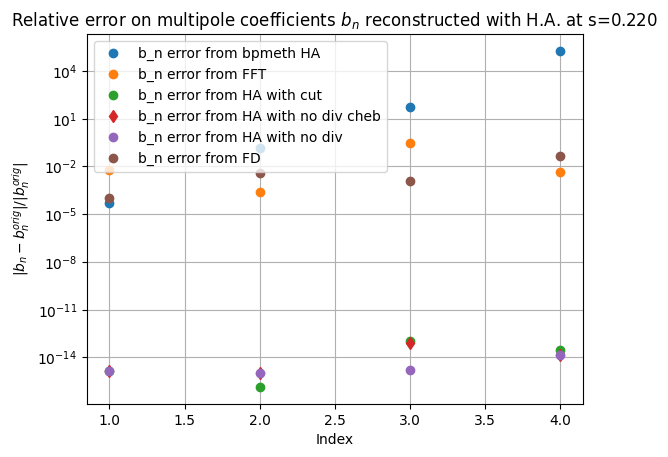

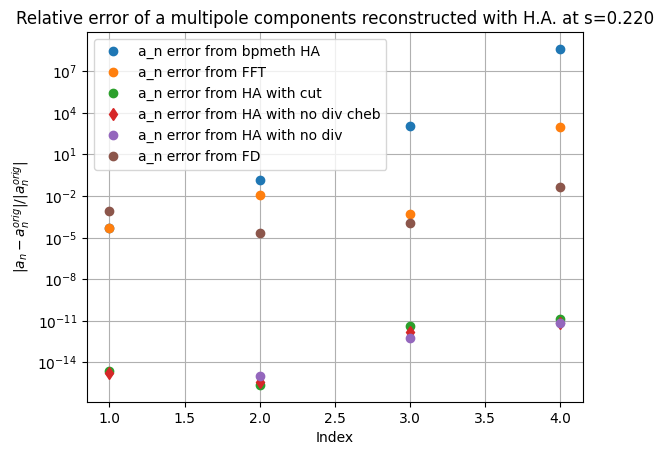

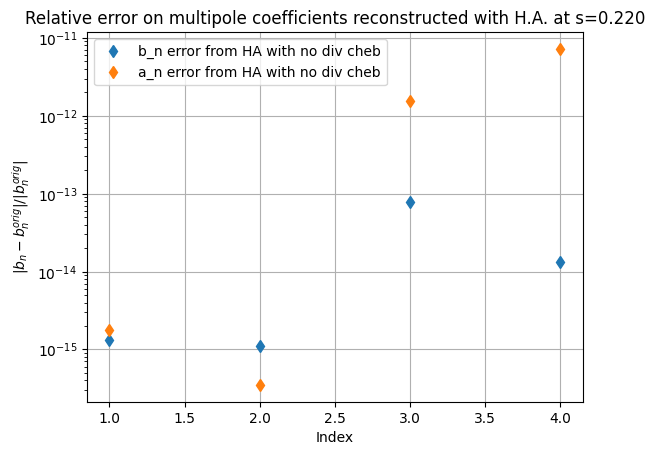

In [27]:
p=4#how many values to plot

plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error on multipole coefficients $b_n$ reconstructed with H.A. at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bn[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from bpmeth HA')
#plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bnori[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from bpmeth HA') #directly from B and not from curl
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bnfft[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from FFT')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_cut[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from HA with cut' )
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_nodiv_cheb[:p])/b_eva(s_fixed)[:p], "d",label='b_n error from HA with no div cheb')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_nodiv[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from HA with no div' )
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-b_FD[:p,sindex])/b_eva(s_fixed)[:p], 'o', label='b_n error from FD' )
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.grid(True)
plt.show()

plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error of a multipole components reconstructed with H.A. at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-an[:p])/a_eva(s_fixed)[:p], 'o', label='a_n error from bpmeth HA')
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-anfft[:p])/a_eva(s_fixed)[:p], 'o', label='a_n error from FFT')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-acurl_cut[:p])/a_eva(s_fixed)[:p], 'o', label='a_n error from HA with cut' )
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-acurl_nodiv_cheb[:p])/a_eva(s_fixed)[:p], "d",label='a_n error from HA with no div cheb' )
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-acurl_nodiv[:p])/a_eva(s_fixed)[:p], 'o', label='a_n error from HA with no div' )
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-a_FD[:p,sindex])/a_eva(s_fixed)[:p], 'o', label='a_n error from FD' )
plt.legend()
plt.ylabel('$|a_n - a_n^{orig}|/|a_n^{orig}|$')
plt.grid(True)
plt.show()

plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error on multipole coefficients reconstructed with H.A. at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl_nodiv_cheb[:p])/b_eva(s_fixed)[:p], "d",label='b_n error from HA with no div cheb')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-acurl_nodiv_cheb[:p])/a_eva(s_fixed)[:p], "d",label='a_n error from HA with no div cheb' )
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.grid(True)
plt.show()

bpmeth local harmonic analysis as function of s

In [30]:
svalues, bpmbofs, bpmerrorbofs = curlfieldmap.s_harmonics(order=4,rmin=rr[24], rmax=rmax, nr=nr-24, ntheta=ntheta,radius=0.007 )

KeyboardInterrupt: 

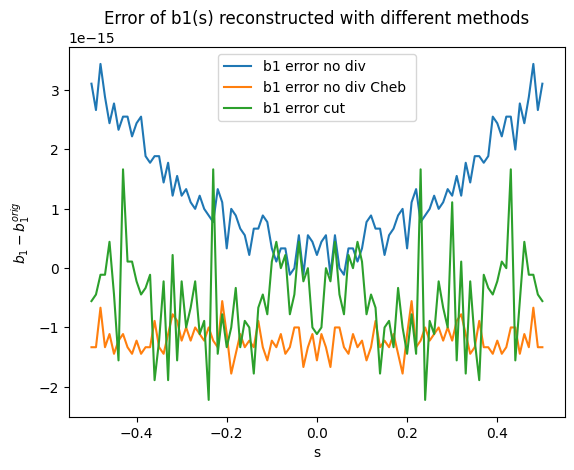

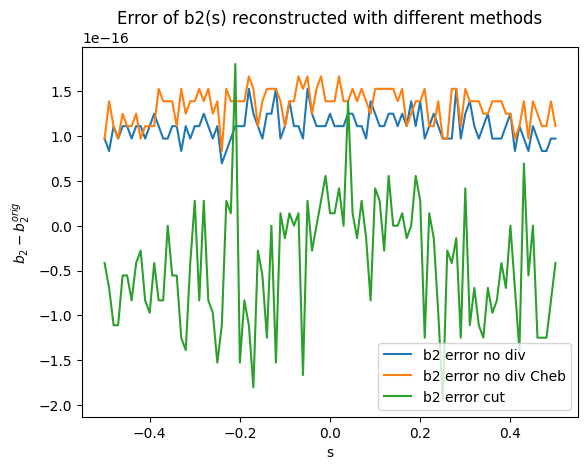

In [17]:
def LH_s_nodiv(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid_nodiv(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs
def LH_s_nodiv_cheb(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))
    aofs = np.zeros((len(svals), korder))
    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        aofs[i], bofs[i] = LHongrid_nodiv_cheb(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, aofs, bofs

_, bofs_nodiv = LH_s_nodiv(fieldyix=fieldyplusifieldx,ss=ss, korder=4)
_, aofs_nodiv_cheb, bofs_nodiv_cheb = LH_s_nodiv_cheb(fieldyix=fieldyplusifieldx,ss=ss, korder=6)


plt.plot(sss, bofs_nodiv[:,0]-b_eva(sss)[0], label='b1 error no div')
plt.plot(sss, (bofs_nodiv_cheb[:,0]-b_eva(sss)[0]), label='b1 error no div Cheb ')
plt.plot(sss, bofs_cut[:,0]-b_eva(sss)[0], label='b1 error cut')
#plt.plot(sss, b_FD[0,:]-b_eva(sss)[0], label='b1 error FD' )
#plt.plot(sss, (bpmbofs[:,0]-b_eva(sss)[0]), label='b1 error bpmeth HA')
plt.legend()
plt.xlabel('s')
plt.ylabel('$b_1 - b_1^{orig}$')
plt.title('Error of b1(s) reconstructed with different methods')
plt.show()


plt.plot(sss, bofs_nodiv[:,1]-b_eva(sss)[1], label='b2 error no div')
plt.plot(sss, (bofs_nodiv_cheb[:,1]-b_eva(sss)[1]), label='b2 error no div Cheb')
plt.plot(sss, bofs_cut[:,1]-b_eva(sss)[1], label='b2 error cut')
#plt.plot(sss, b_FD[1,:]-b_eva(sss)[1], label='b2 error FD' )
#plt.plot(sss, (bpmbofs[:,1]-b_eva(sss)[1])*1e-4, label='b2 error bpmeth HA *1e-4')
plt.legend()
plt.xlabel('s')
plt.ylabel('$b_2 - b_2^{orig}$')
plt.title('Error of b2(s) reconstructed with different methods')
plt.show()

NameError: name 'bpmbofs' is not defined

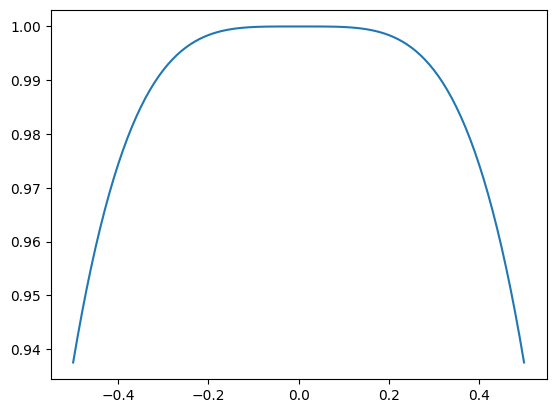

In [32]:
plt.plot(sss, b_eva(sss)[0], label="original b1")
plt.plot(ss, bpmbofs[:,0], label="b1(s) from bpmeth")
plt.fill_between(sss, bpmbofs[:,0]+bpmerrorbofs[:,0], bpmbofs[:,0]-bpmerrorbofs[:,0], color='orange', alpha=0.2, label='bpmeth HA error band')
plt.plot(sss, bofs_cut[:,0], label='b1 from HA with cut')
plt.plot(sss, bofs_nodiv[:,0], label='b1 from HA with no div')
plt.plot(sss, bofs_nodiv_cheb[:,0], label='b1 from HA with no div cheb')
plt.plot(sss, b_FD[0,:], label='b1 FD' )
plt.legend()
plt.xlabel('s')
#plt.ylim((1-6e-15,1+6e-15))
plt.title('b1(s) reconstructed with different methods')
plt.show()
plt.plot(ss, b_eva(ss)[1]*np.ones_like(ss), label="original b2")
plt.plot(ss, bpmbofs[:,1], label="b2(s) from bpmeth")
plt.fill_between(sss, bpmbofs[:,1]+bpmerrorbofs[:,1], bpmbofs[:,1]-bpmerrorbofs[:,1], color='orange', alpha=0.1, label='bpmeth HA error band')
plt.plot(ss, bofs_cut[:,1], label='b2 from HA with cut')
plt.plot(ss, bofs_nodiv[:,1], label='b2 from HA with no div')
plt.plot(ss, bofs_nodiv_cheb[:,1], label='b2 from HA with no div cheb')
plt.plot(sss, b_FD[1,:], label='b2 error FD' )
plt.legend()
plt.xlabel('s')
plt.title('b2(s) reconstructed with different methods')
plt.show()
plt.plot(ss, b_eva(ss)[2]*np.ones_like(ss), label="original b3")
plt.plot(ss, bpmbofs[:,2], label="b3(s) from bpmeth")
plt.fill_between(sss, bpmbofs[:,2]+bpmerrorbofs[:,2], bpmbofs[:,2]-bpmerrorbofs[:,2], color='orange', alpha=0.1, label='bpmeth HA error band')
plt.plot(ss, bofs_cut[:,2], label='b3 from HA with cut')
plt.plot(ss, bofs_nodiv[:,2], label='b3 from HA with no div')
plt.plot(ss, bofs_nodiv_cheb[:,2], label='b3 from HA with no div cheb')
plt.plot(sss, b_FD[2,:], label='b3 error FD' )
plt.legend()
plt.xlabel('s')
plt.show()

Timing

In [ ]:
# import cProfile
# cProfile.run('dklfitraw_nodiv_cheb(dkgridout, rr, nk, nl)', sort='cumulative')
# cProfile.run('dklfitraw_nodiv(dkgridout, rr, nk, nl)', sort='cumulative')
import timeit
t = timeit.timeit(lambda: dklfitraw_nodiv_cheb(dkgridout, rr, nk, nl), number=100)
print(f"Total nodiv_cheb: {t:.3f}s  —  per call: {t/100*1000:.2f}ms")
t = timeit.timeit(lambda: dklfitraw_nodiv(dkgridout, rr, nk, nl), number=100)
print(f"Total nodiv: {t:.3f}s  —  per call: {t/100*1000:.2f}ms")
t = timeit.timeit(lambda: LH_s_nodiv_cheb(fieldyix=fieldyplusifieldx, ss=ss,korder=4), number =100)
print(f"Total LH_s_nodiv_cheb: {t:.3f}s  —  per call: {t/100*1000:.2f}ms")
t = timeit.timeit(lambda: LH_s_nodiv(fieldyix=fieldyplusifieldx, ss=ss,korder=4), number =100)
print(f"Total LH_s_nodiv: {t:.3f}s  —  per call: {t/100*1000:.2f}ms")


Total nodiv_cheb: 0.187s  —  per call: 1.87ms
Total nodiv: 0.027s  —  per call: 0.27ms
Total LH_s_nodiv_cheb: 8.206s  —  per call: 82.06ms
Total LH_s_nodiv: 2.752s  —  per call: 27.52ms


Reconstruct the B field

(101, 6) (101, 6)
fit on reconstruction ['-2.79054925149708e-13*s**8 - 1.02336488321006e-13*s**7 + 2.50397916859415e-13*s**6 + 3.28309824583443e-14*s**5 - 1.00000000000006*s**4 - 1.37348490848056e-15*s**3 + 5.72567910567677e-15*s**2 - 1.17190069284784e-16*s + 0.999999999999999', '-2.74969390028467e-13*s**8 + 5.11682441605029e-15*s**7 + 7.62487585236092e-14*s**6 - 2.06387880283361e-15*s**5 - 4.22001326643946e-16*s**4 + 8.34915227304754e-17*s**3 - 4.46687517737841e-16*s**2 - 5.31092301862169e-18*s + 0.1', '3.17219910136237e-11*s**8 - 6.9588812058284e-13*s**7 - 1.60740760384877e-11*s**6 + 2.46318533914404e-13*s**5 + 2.58319030831752e-12*s**4 - 1.93556334350517e-14*s**3 - 1.38389944474276e-13*s**2 + 1.81078747873074e-16*s + 0.400000000000028', '9.2406278118258e-12*s**8 - 1.43271083649408e-12*s**7 - 4.11791846617905e-12*s**6 + 6.41066953442967e-13*s**5 + 6.43636224768756e-13*s**4 - 9.16011263767724e-14*s**3 - 0.400000000000051*s**2 + 3.96129848032051e-15*s + 0.500000000000004', '-2.99636532

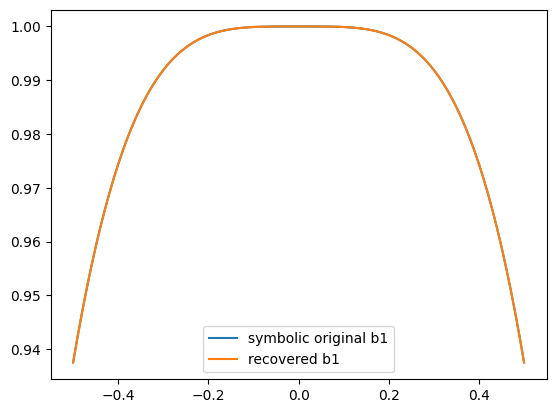

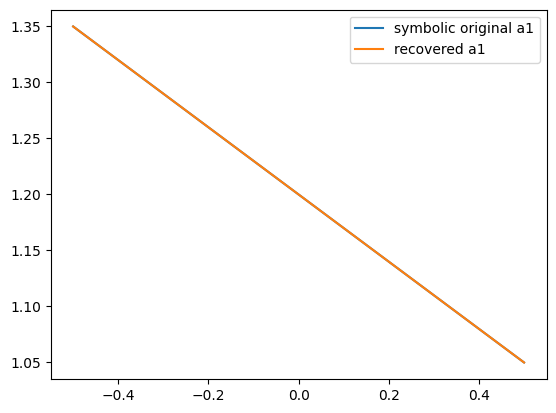

In [18]:
degree = 8
b_nfit_cheb = []
print(bofs_nodiv_cheb.shape, aofs_nodiv_cheb.shape)
for j in range(bofs_nodiv_cheb.shape[1]):
    coeffs = np.polyfit(ss, bofs_nodiv_cheb[:,j], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit_cheb.append(str(poly_expr))

a_nfit_cheb=[]

for j in range(aofs_nodiv_cheb.shape[1]):
    coeffs = np.polyfit(ss, aofs_nodiv_cheb[:, j], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    a_nfit_cheb.append(str(poly_expr))

print("fit on reconstruction", b_nfit_cheb)
print("original",b_coeffs)
plt.plot(ss, 1-ss**4, label="symbolic original b1")
s = sp.symbols('s')
b1ofslambdified = lambdify(s, b_nfit_cheb[0], modules='numpy')
plt.plot(ss, b1ofslambdified(ss), label='recovered b1')
plt.legend()
plt.show()
plt.plot(ss, 1.2-0.3*ss, label="symbolic original a1")
a1ofslambdified = lambdify(s, a_nfit_cheb[0], modules='numpy')
plt.plot(ss, a1ofslambdified(ss), label='recovered a1')
plt.legend()
plt.show()


reconstruction grid shape: (128, 256, 101) (128, 256, 101) (128, 256, 101)


/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:181: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


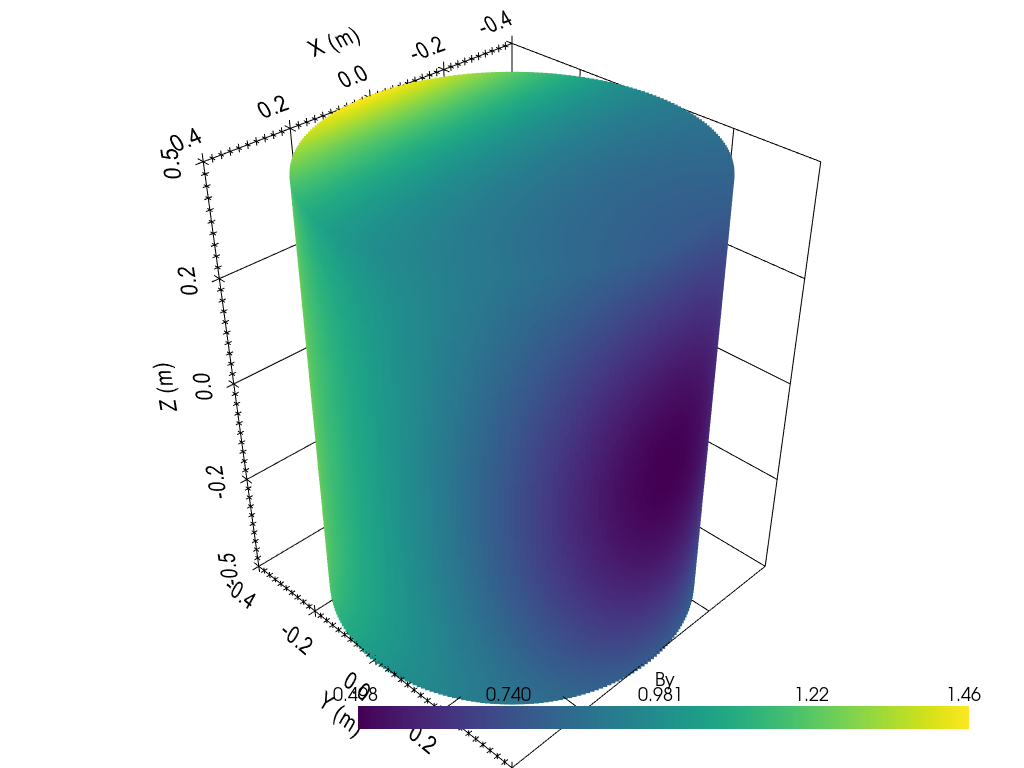

In [19]:
reconstruction_nodiv_cheb=bpmeth.FieldExpansion(a=a_nfit_cheb, b=b_nfit_cheb, nphi=6)
# make a fieldmap of this reconstruction using the original Cartesian grid
Bx_rec_nodiv_cheb, By_rec_nodiv_cheb, Bs_rec_nodiv_cheb = reconstruction_nodiv_cheb.get_Bfield(lambdify=True)
X, Y, S = xarr, yarr, sarr
print('reconstruction grid shape:', X.shape, Y.shape, S.shape)
Bx_rec_mesh = Bx_rec_nodiv_cheb(X, Y, S)
By_rec_mesh = By_rec_nodiv_cheb(X, Y, S)
Bs_rec_mesh = Bs_rec_nodiv_cheb(X, Y, S)
reconfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_rec_mesh.ravel(),
    By_rec_mesh.ravel(),
    Bs_rec_mesh.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm_rec = bpmeth.fieldmaps.Fieldmap(reconfieldmap)
fm_rec.plot()


(128, 256, 101) (128, 256, 101) (128, 256, 101)
(128, 256, 101) (128, 256, 101) (128, 256, 101)
(128, 256, 101) (128, 256, 101) (128, 256, 101)


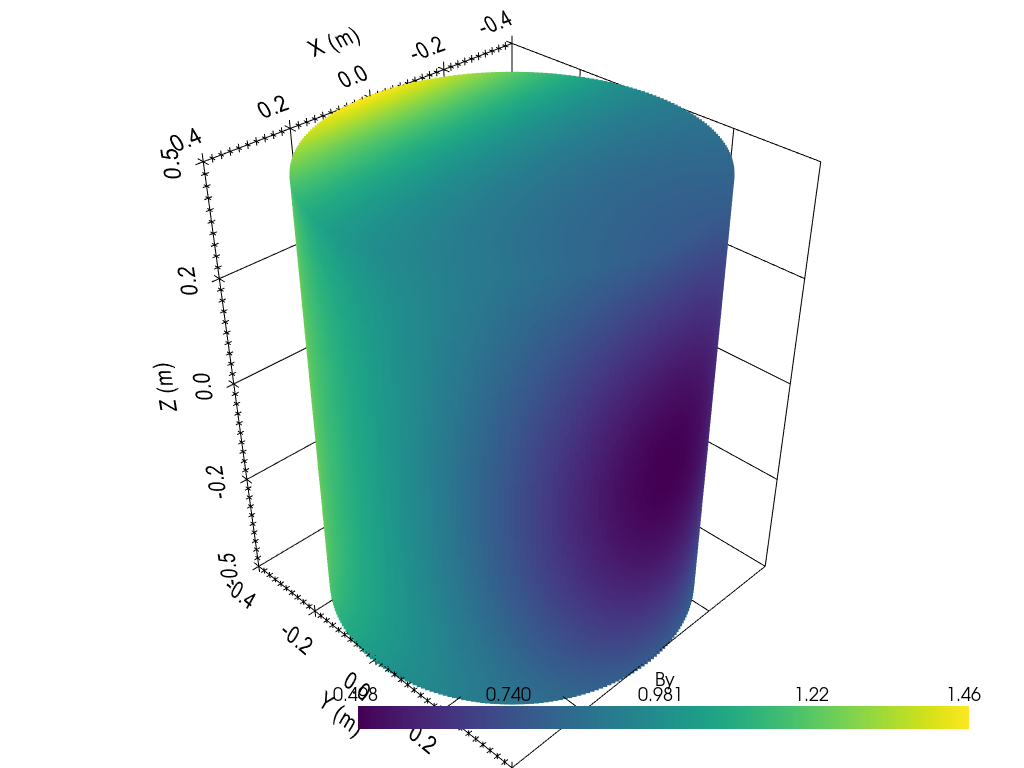

In [20]:
#make a fieldmap from the original expansion
print(X.shape, Y.shape, S.shape)
print(Bx_ana.shape, By_ana.shape, Bs_ana.shape)
Bx_anaxys = Bx_func(X,Y,S)
By_anaxys = By_func(X,Y,S)
Bs_anaxys= Bs_func(X,Y,S)
print(Bx_anaxys.shape, By_anaxys.shape, Bs_anaxys.shape)
originaldatafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_anaxys.ravel(),
    By_anaxys.ravel(),
    Bs_anaxys.ravel()
])
fm = bpmeth.fieldmaps.Fieldmap(originaldatafieldmap)
fm.plot()

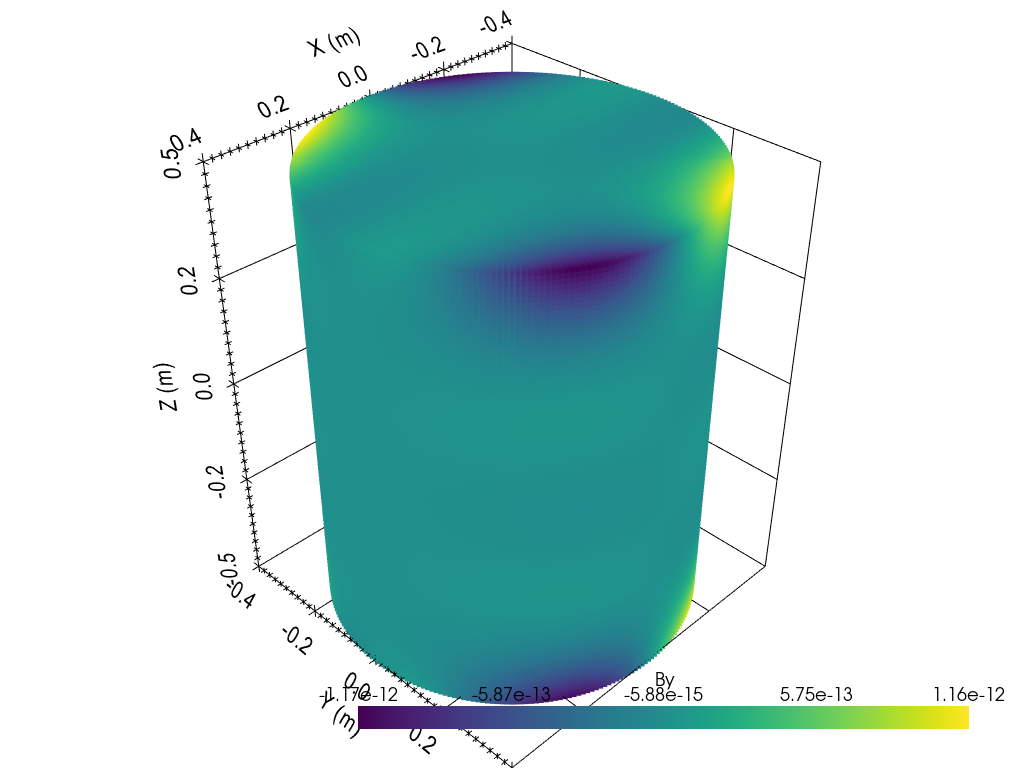

In [21]:
#make a fieldmap of the difference between the reconstruction and the original
resx=Bx_rec_mesh-Bx_anaxys
resy=By_rec_mesh-By_anaxys
ress=Bs_rec_mesh-Bs_anaxys
residualfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    resx.ravel(),
    resy.ravel(),
    ress.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fmresidual = bpmeth.fieldmaps.Fieldmap(residualfieldmap)
fmresidual.plot()